In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
historical_df = pd.read_csv("../data/historical_data.csv")
sentiment_df = pd.read_csv("../data/fear_greed_index.csv")

In [37]:
historical_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [38]:
historical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [39]:
historical_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

In [40]:
historical_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [41]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [42]:
sentiment_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [43]:
sentiment_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [44]:
sentiment_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [45]:
# historical_df['Timestamp IST'].head()

historical_df['Timestamp IST'] = pd.to_datetime(
    historical_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [46]:
historical_df['date'] = historical_df['Timestamp IST'].dt.date

In [47]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

In [48]:
historical_df[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [49]:
sentiment_df['date'].head()

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object

In [50]:
merged_df = pd.merge(
    historical_df,
    sentiment_df,
    on='date',
    how='left'
)

In [51]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [52]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  str           
 6   Timestamp IST     211224 non-null  datetime64[us]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  str           
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  str           
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trade ID       

In [53]:
merged_df[['date', 'classification']].head(20)

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed
5,2024-12-02,Extreme Greed
6,2024-12-02,Extreme Greed
7,2024-12-02,Extreme Greed
8,2024-12-02,Extreme Greed
9,2024-12-02,Extreme Greed


In [54]:
merged_df['classification'].isnull().sum()

np.int64(6)

In [55]:
merged_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='str')

In [57]:
merged_df.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [58]:
merged_df.groupby('classification')['Closed PnL'].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.0,34.537862,1136.056091,-31036.69194,0.0,0.0,5.635032,115287.00000
Extreme Greed,39992.0,67.892861,766.828294,-10259.46800,0.0,0.0,10.028709,44223.45187
Fear,61837.0,54.290400,935.355438,-35681.74723,0.0,0.0,5.590856,135329.09010
Greed,50303.0,42.743559,1116.028390,-117990.10410,0.0,0.0,4.944105,74530.52371
Neutral,37686.0,34.307718,517.122220,-24500.00000,0.0,0.0,3.995795,48504.09555


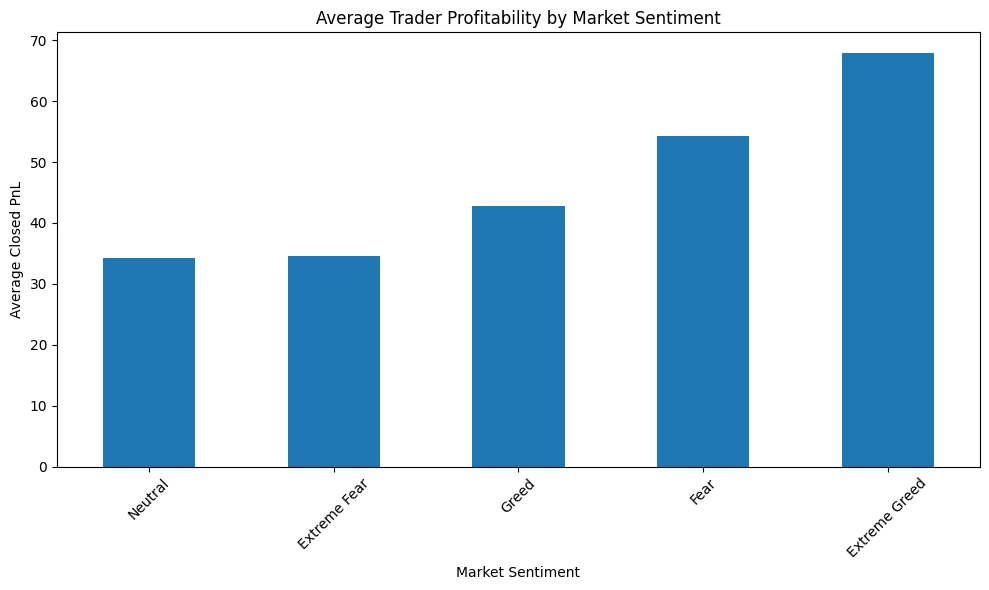

In [61]:
plt.figure(figsize=(10, 6))

merged_df.groupby('classification')['Closed PnL'].mean().sort_values().plot(
    kind='bar'
)

plt.title('Average Trader Profitability by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

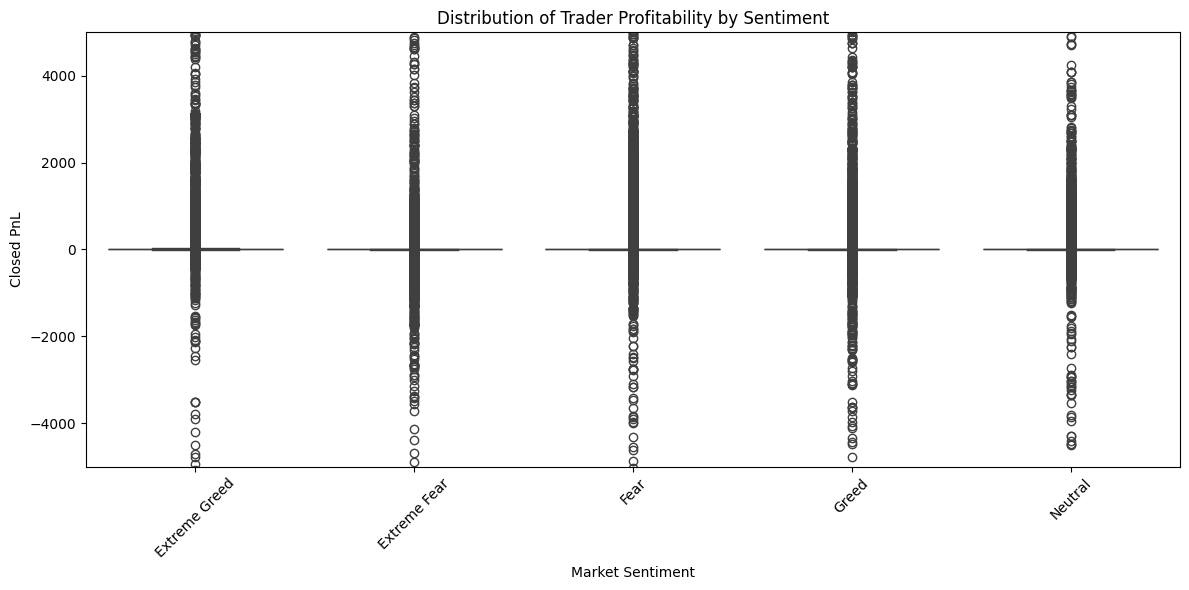

In [62]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=merged_df,
    x='classification',
    y='Closed PnL'
)

plt.title('Distribution of Trader Profitability by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL')

plt.ylim(-5000, 5000)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [64]:
merged_df['is_profit'] = merged_df['Closed PnL'] > 0

In [65]:
win_rate = merged_df.groupby('classification')['is_profit'].mean() * 100

win_rate.sort_values()

classification
Extreme Fear     37.060748
Greed            38.482794
Neutral          39.699093
Fear             42.076750
Extreme Greed    46.494299
Name: is_profit, dtype: float64

In [66]:
trade_count = merged_df.groupby('classification').size()

trade_count.sort_values()

classification
Extreme Fear     21400
Neutral          37686
Extreme Greed    39992
Greed            50303
Fear             61837
dtype: int64

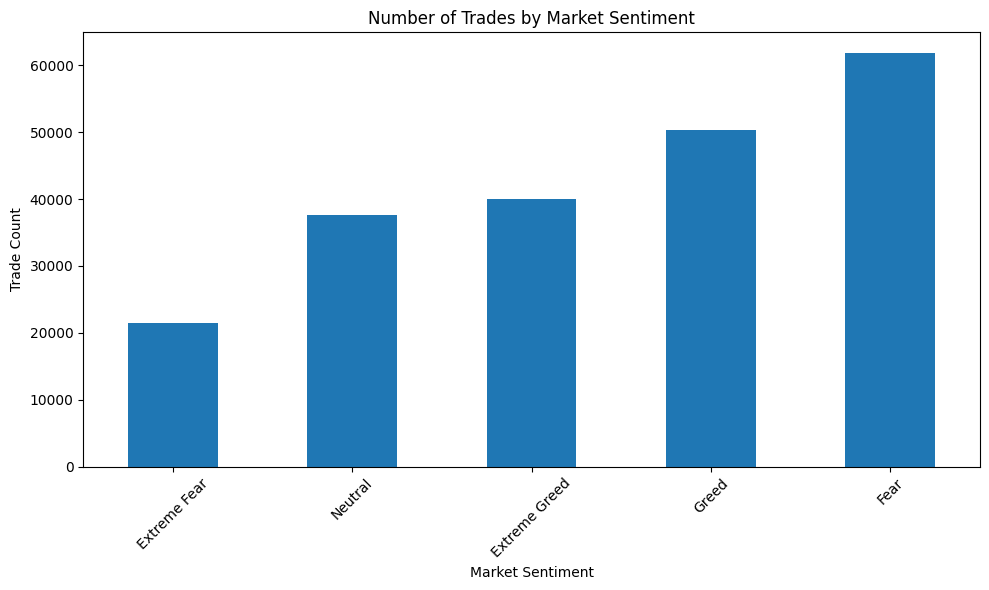

In [ ]:
plt.figure(figsize=(10, 6))

trade_count.sort_values().plot(kind='bar')

plt.title('Number of Trades by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Trade Count')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [68]:
merged_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification',
       'is_profit'],
      dtype='str')

In [70]:
merged_df.groupby('classification')['Size USD'].mean().sort_values()

classification
Extreme Greed    3112.251565
Neutral          4782.732661
Extreme Fear     5349.731843
Greed            5736.884375
Fear             7816.109931
Name: Size USD, dtype: float64

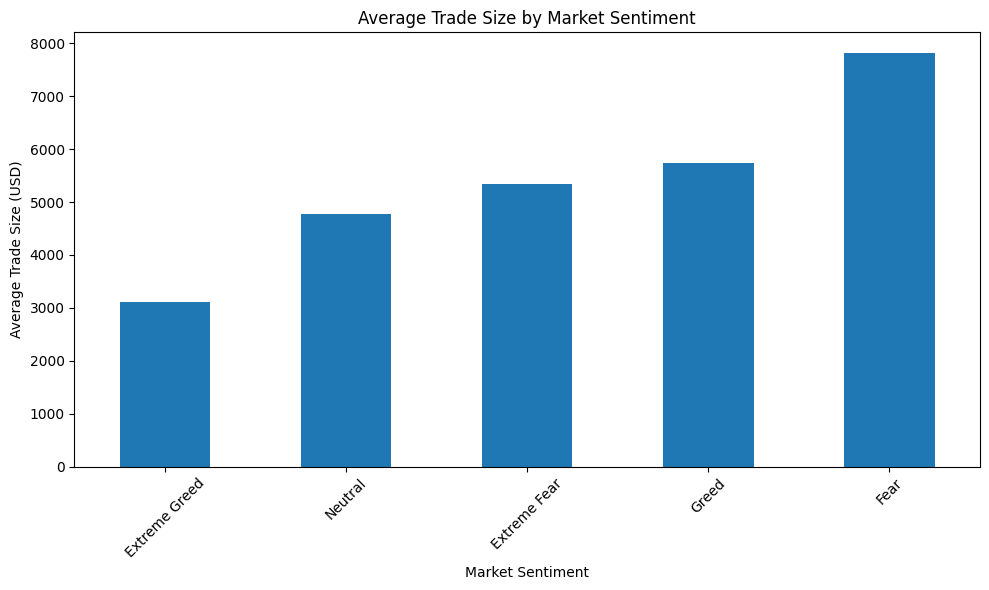

In [71]:
plt.figure(figsize=(10, 6))

merged_df.groupby('classification')['Size USD'].mean().sort_values().plot(
    kind='bar'
)

plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Trade Size (USD)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [72]:
merged_df.groupby('classification')['Fee'].mean().sort_values()

classification
Extreme Greed    0.675902
Neutral          1.044798
Extreme Fear     1.116291
Greed            1.254372
Fear             1.495172
Name: Fee, dtype: float64

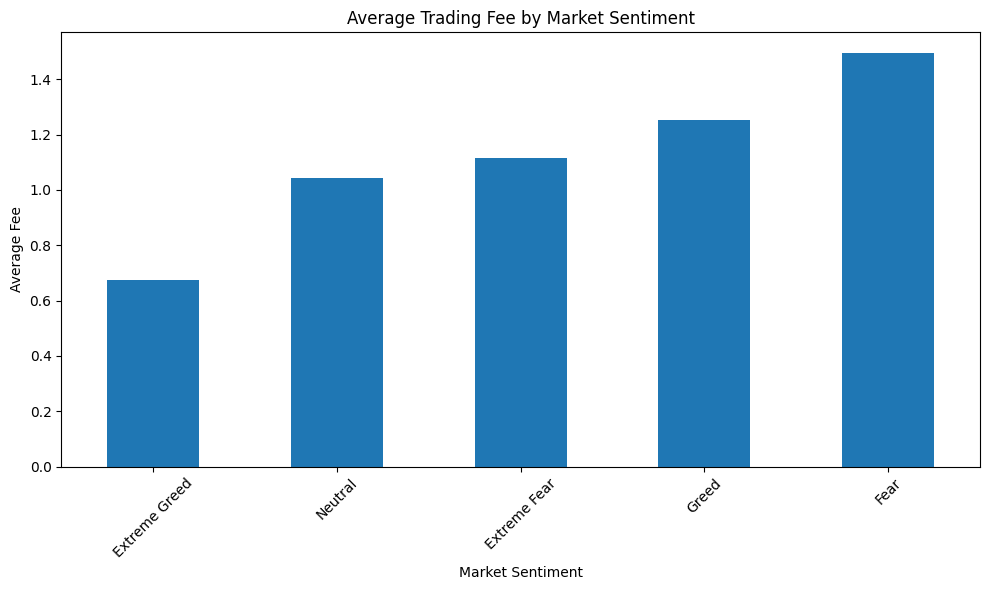

In [73]:
plt.figure(figsize=(10, 6))

merged_df.groupby('classification')['Fee'].mean().sort_values().plot(
    kind='bar'
)

plt.title('Average Trading Fee by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Fee')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [74]:
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Start Position',
    'Closed PnL',
    'Fee',
    'value'
]

corr_df = merged_df[numeric_cols]

In [75]:
correlation_matrix = corr_df.corr()

correlation_matrix

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Fee,value
Execution Price,1.000000,-0.017185,0.189855,0.017241,-0.006505,0.225265,-0.027558
Size Tokens,-0.017185,1.000000,0.013310,0.044660,0.005068,0.006710,0.023080
Size USD,0.189855,0.013310,1.000000,0.007787,0.123589,0.745939,-0.029843
Start Position,0.017241,0.044660,0.007787,1.000000,0.004066,0.010559,-0.049619
Closed PnL,-0.006505,0.005068,0.123589,0.004066,1.000000,0.084020,0.008121
Fee,0.225265,0.006710,0.745939,0.010559,0.084020,1.000000,-0.026877
value,-0.027558,0.023080,-0.029843,-0.049619,0.008121,-0.026877,1.000000


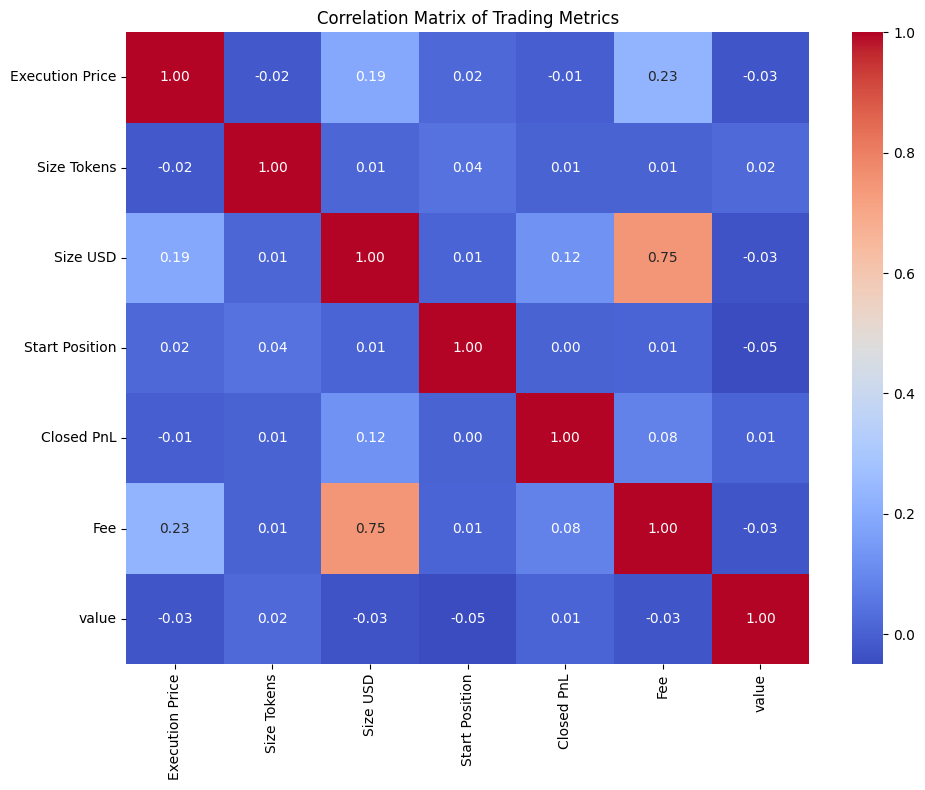

In [76]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Trading Metrics')

plt.tight_layout()
plt.show()